# Data Exploration
Explores the pre-processed dataset (`data/images.npy`, `data/labels.npy`, and the source catalogue CSV).
Images are already resized to 89×89 grayscale uint8. No re-processing is done here.
Includes a brightness-based filter to identify and remove extremely faint sources.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')

## Load data

In [12]:
images = np.load(DATA_DIR / 'images.npy')
labels = np.load(DATA_DIR / 'labels.npy')
csv    = pd.read_csv(DATA_DIR / 'classifications_horton_et_al_2025_filtered.csv')

LABEL_NAMES = np.array([
    # initial (0–4)
    'FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles',
    # morphology (5–14)
    'C-curvature', 'S-curvature', 'Misalignment', 'Wings', 'X-shaped',
    'Straight jets', 'Multiple hotspots', 'Continuous jets', 'Banding', 'One-sided',
    # environment (15–18)
    'Cluster', 'Merger', 'Diffuse emission', 'Unknown',
    # derived (19)
    'Restarted',
])

print(f'Images : {images.shape}  dtype={images.dtype}')
print(f'Labels : {labels.shape}  dtype={labels.dtype}')
print(f'CSV    : {csv.shape}  columns={list(csv.columns)}')
print(f'Pixel range : [{images.min()}, {images.max()}]  (uint8, 0–255)')

Images : (7607, 89, 89)  dtype=uint8
Labels : (7607, 20)  dtype=float64
CSV    : (7607, 36)  columns=['Source_Name', 'z_best', 'Size', 'angular_size', 'L_144', 'Mass_median', 'flag_mass', 'fri', 'frii', 'hybrid', 'spiral', 'relaxed', 'cshaped', 'sshaped', 'misaligned', 'wings', 'xshaped', 'straight', 'multihotspots', 'continuous', 'banding', 'onesided', 'restarted', 'cluster', 'merger', 'diffuse', 'unknown', 'featurecount', 'hasanyone', 'hasanytwo', 'hasall', 'has_exactly_1', 'has_exactly_2', 'se', 'ms', 'em']
Pixel range : [4, 255]  (uint8, 0–255)


## Sample images

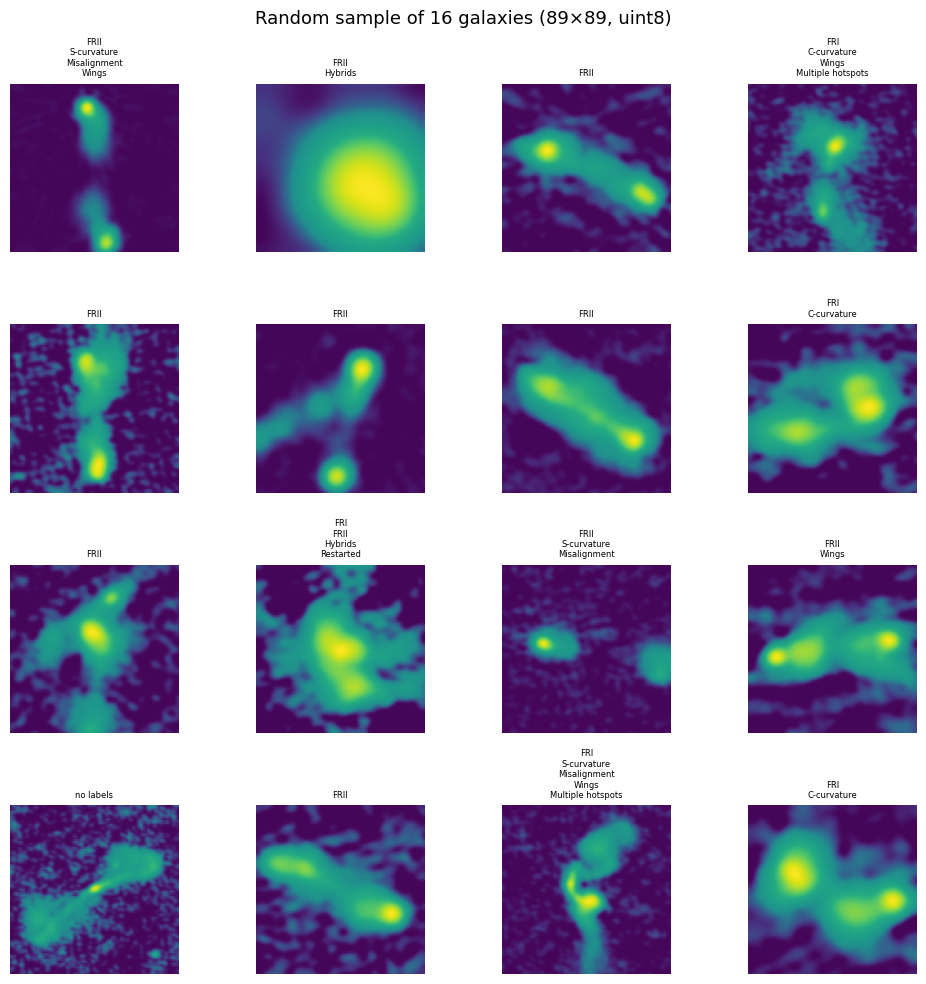

In [14]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(images), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Random sample of 16 galaxies (89×89, uint8)', fontsize=13)
for ax, i in zip(axes.flat, sample_idx):
    ax.imshow(images[i], cmap='viridis', origin='lower', vmin=0, vmax=255)
    active = LABEL_NAMES[labels[i].astype(bool)]
    title_str = '\n'.join(active) if len(active) > 0 else 'no labels'
    ax.set_title(title_str, fontsize=6)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Label distribution

Total label occurrences: 16280


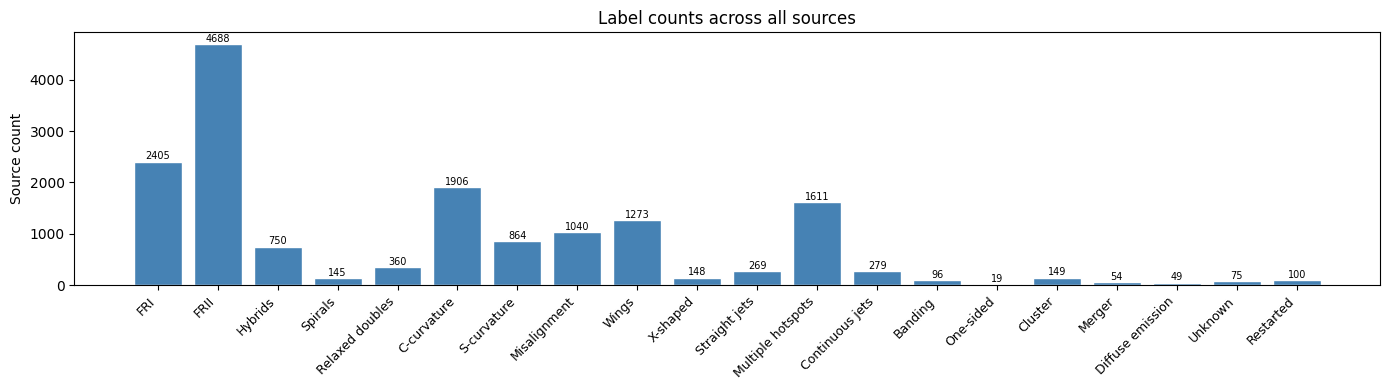

In [15]:
counts = labels.sum(axis=0)
print(f'Total label occurrences: {int(counts.sum())}')

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(range(len(counts)), counts, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Source count')
ax.set_title('Label counts across all sources')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(c)), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

## Label co-occurrence
Since galaxies can have multiple labels, we check which features appear together.

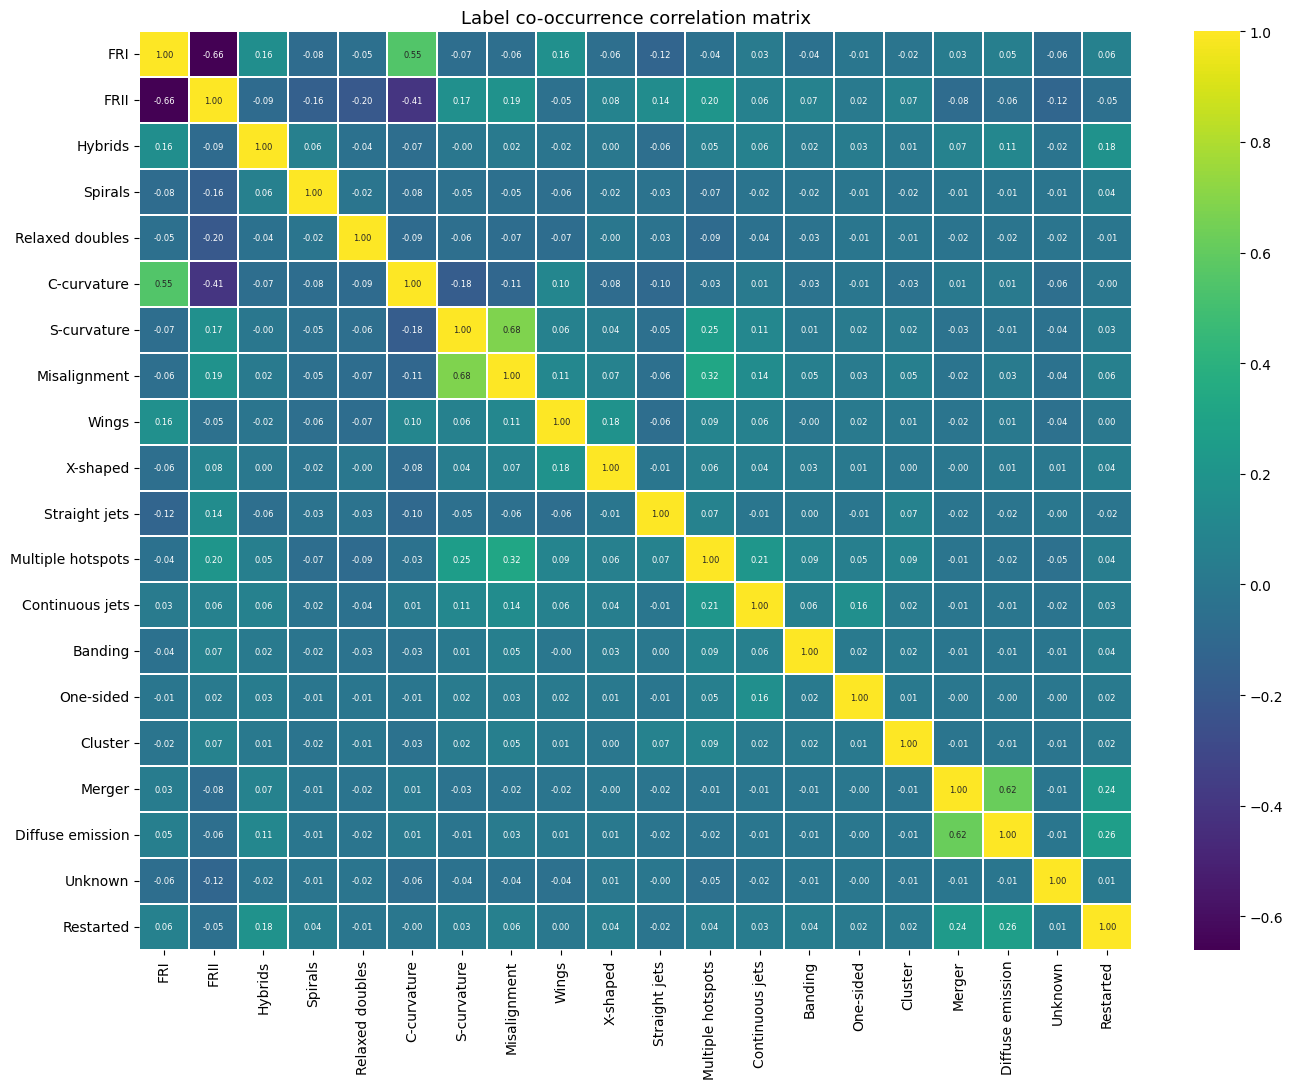

In [16]:
labels_df = pd.DataFrame(labels, columns=LABEL_NAMES)
co_occurrence = labels_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(co_occurrence, annot=True, fmt='.2f', cmap='viridis',
            annot_kws={'size': 6}, linewidths=0.3, ax=ax)
ax.set_title('Label co-occurrence correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

## Redshift distribution

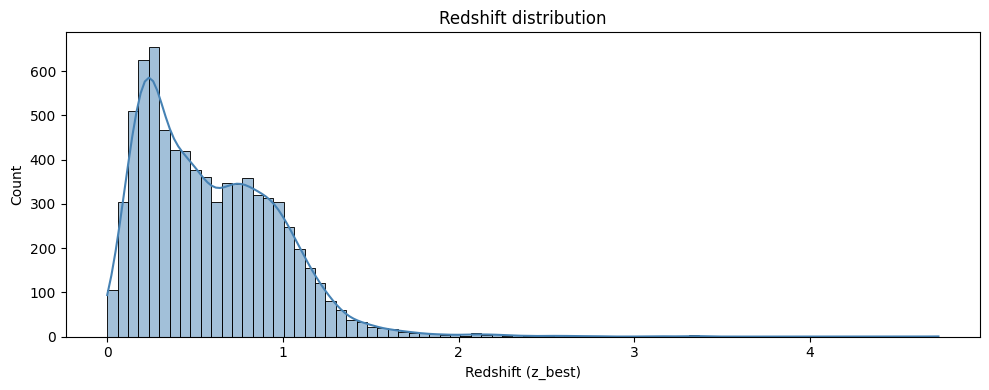

count    7607.000000
mean        0.586598
std         0.386490
min         0.000009
25%         0.265506
50%         0.518322
75%         0.848947
max         4.731280
Name: z_best, dtype: float64


In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(csv['z_best'].dropna(), bins=80, kde=True, ax=ax, color='steelblue')
ax.set_xlabel('Redshift (z_best)')
ax.set_ylabel('Count')
ax.set_title('Redshift distribution')
plt.tight_layout()
plt.show()

print(csv['z_best'].describe())

### Redshift vs. morphological class

/tmp/ipykernel_121867/4045329431.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)


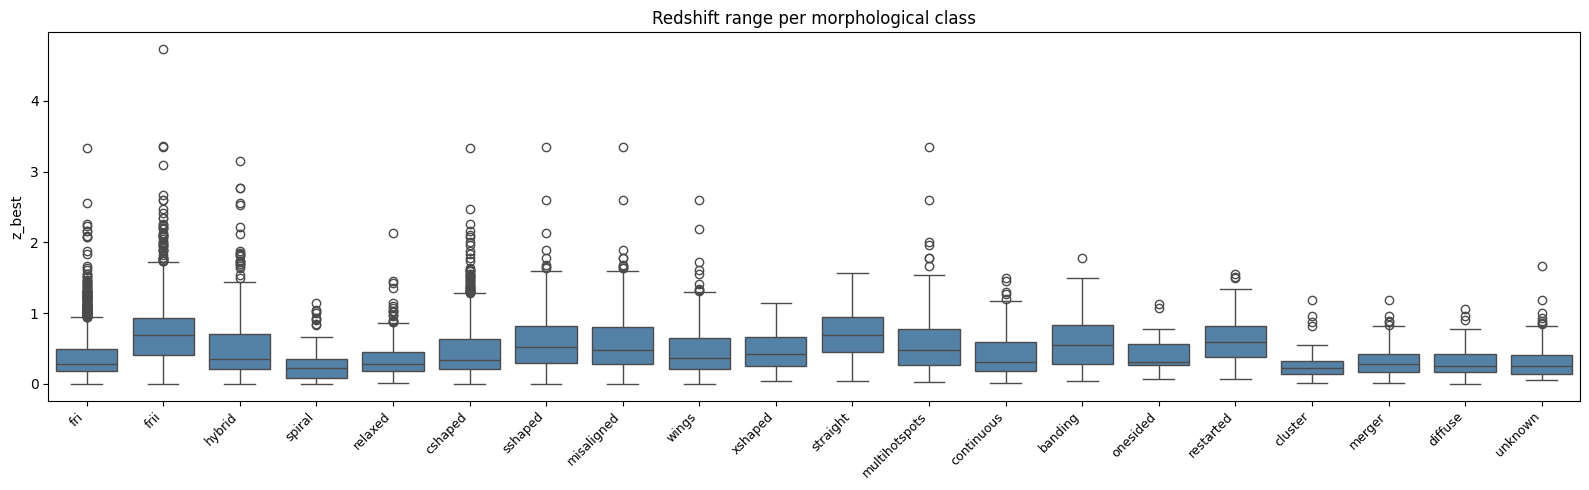

In [19]:
CSV_LABEL_COLS = ['fri', 'frii', 'hybrid', 'spiral', 'relaxed', 'cshaped',
                  'sshaped', 'misaligned', 'wings', 'xshaped', 'straight',
                  'multihotspots', 'continuous', 'banding', 'onesided', 'restarted',
                  'cluster', 'merger', 'diffuse', 'unknown']

melted = csv.melt(id_vars=['z_best'], value_vars=CSV_LABEL_COLS,
                  var_name='Class', value_name='Present')
melted = melted[melted['Present'] == 1]

fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(x='Class', y='z_best', data=melted, ax=ax, color='steelblue', showfliers=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_title('Redshift range per morphological class')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## Physical properties
Angular size, physical size, and radio luminosity distributions.

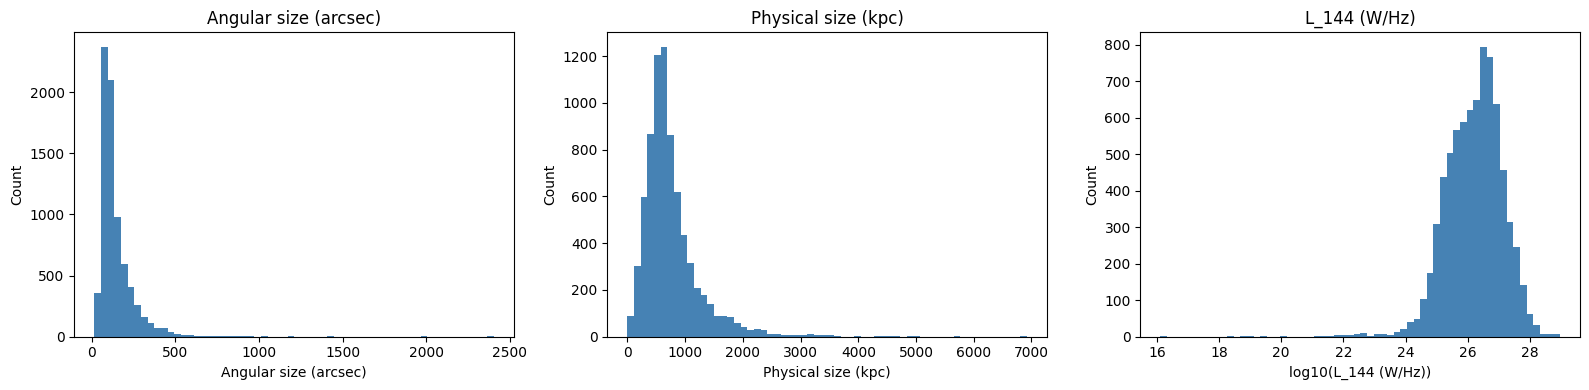

       angular_size         Size         L_144
count   7607.000000  7607.000000  7.607000e+03
mean     143.675275   758.528397  8.977421e+26
std      104.390020   493.550808  3.282918e+27
min       15.441852     0.044632  1.301777e+16
25%       84.646836   466.190600  4.224599e+25
50%      111.215141   643.727420  1.968643e+26
75%      169.408098   900.990272  6.741932e+26
max     2405.315750  6922.076644  9.271958e+28


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, label in zip(axes,
                           ['angular_size', 'Size', 'L_144'],
                           ['Angular size (arcsec)', 'Physical size (kpc)', 'L_144 (W/Hz)']):
    data = csv[col].dropna()
    if col == 'L_144':
        ax.hist(np.log10(data[data > 0]), bins=60, color='steelblue', edgecolor='none')
        ax.set_xlabel(f'log10({label})')
    else:
        ax.hist(data, bins=60, color='steelblue', edgecolor='none')
        ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)

plt.tight_layout()
plt.show()

print(csv[['angular_size', 'Size', 'L_144']].describe())

## Brightness analysis
Per-image peak pixel value (max over spatial dims, in uint8 range 0–255).
Extremely faint sources appear as outliers at the low end.

Peak brightness — min: 139  median: 252  max: 255
  Sources with peak <   5: 0
  Sources with peak <  10: 0
  Sources with peak <  20: 0
  Sources with peak <  30: 0


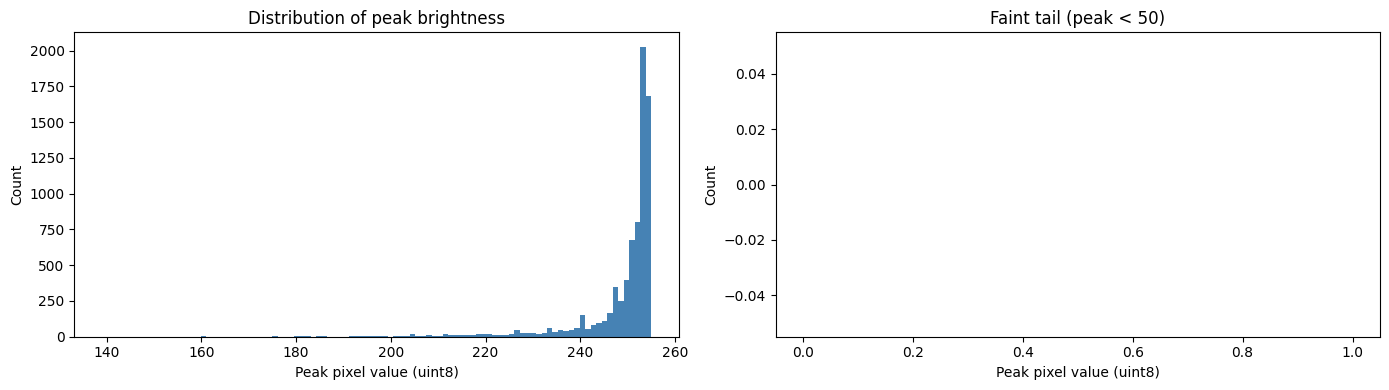


10 faintest sources:
  idx  2258  peak=139
  idx  4077  peak=143
  idx  3065  peak=154
  idx  2249  peak=160
  idx  1963  peak=161
  idx  7428  peak=164
  idx  5210  peak=165
  idx  4165  peak=175
  idx  4900  peak=176
  idx  3311  peak=176

Pixel std — min: 0.0000  median: 56.3556  max: 91.1625
  Sources with std <=    0: 11
  Sources with std <=    1: 11
  Sources with std <=    2: 11
  Sources with std <=    5: 11


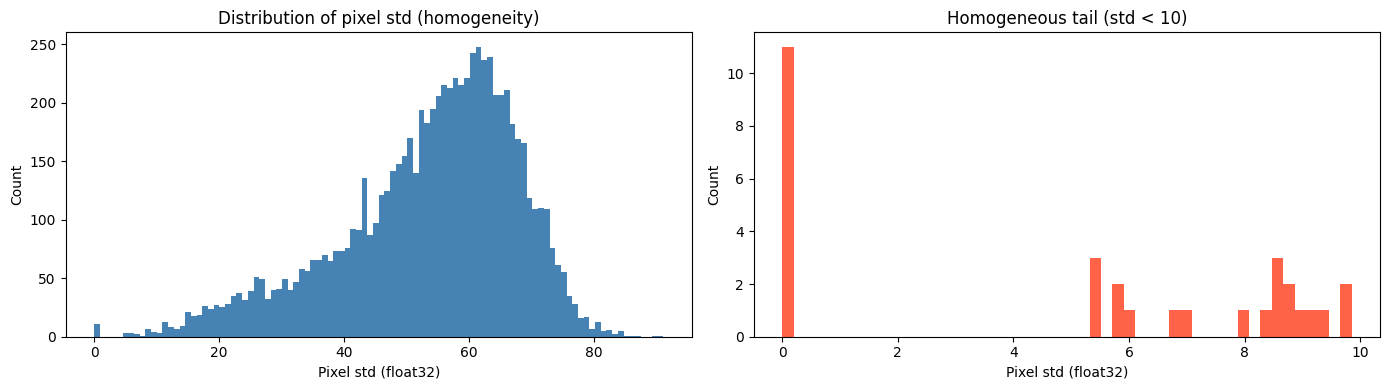


10 most homogeneous sources:
  idx  3733  std=0.0000  peak=255
  idx   506  std=0.0000  peak=255
  idx  1054  std=0.0000  peak=255
  idx  6042  std=0.0000  peak=255
  idx  6098  std=0.0000  peak=255
  idx  7494  std=0.0000  peak=255
  idx  3892  std=0.0000  peak=255
  idx  3498  std=0.0000  peak=255
  idx  6458  std=0.0000  peak=255
  idx   829  std=0.0000  peak=255


In [ ]:
peak = images.max(axis=(1, 2))   # uint8, range [0, 255]
std_per_image = images.astype(np.float32).std(axis=(1, 2))

# --- Peak brightness ----------------------------------------------------------
print(f'Peak brightness — min: {peak.min()}  median: {int(np.median(peak))}  max: {peak.max()}')
for t in [5, 10, 20, 30]:
    print(f'  Sources with peak < {t:3d}: {(peak < t).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(peak, bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Peak pixel value (uint8)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of peak brightness')

axes[1].hist(peak[peak < 200], bins=50, color='tomato', edgecolor='none')
axes[1].set_xlabel('Peak pixel value (uint8)')
axes[1].set_ylabel('Count')
axes[1].set_title('Faint tail (peak < 200)')
plt.tight_layout()
plt.show()

print('\n10 faintest sources:')
for i in np.argsort(peak)[:40]:
    print(f'  idx {i:5d}  peak={peak[i]}')

# --- Pixel std (homogeneity) --------------------------------------------------
print(f'\nPixel std — min: {std_per_image.min():.4f}  median: {np.median(std_per_image):.4f}  max: {std_per_image.max():.4f}')
for t in [0, 1, 2, 5]:
    print(f'  Sources with std <= {t:>4}: {(std_per_image <= t).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(std_per_image, bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Pixel std (float32)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of pixel std (homogeneity)')

axes[1].hist(std_per_image[std_per_image < 10], bins=50, color='tomato', edgecolor='none')
axes[1].set_xlabel('Pixel std (float32)')
axes[1].set_ylabel('Count')
axes[1].set_title('Homogeneous tail (std < 10)')
plt.tight_layout()
plt.show()

print('\n10 most homogeneous sources:')
for i in np.argsort(std_per_image)[:10]:
    print(f'  idx {i:5d}  std={std_per_image[i]:.4f}  peak={peak[i]}')

### Visualise the faintest sources

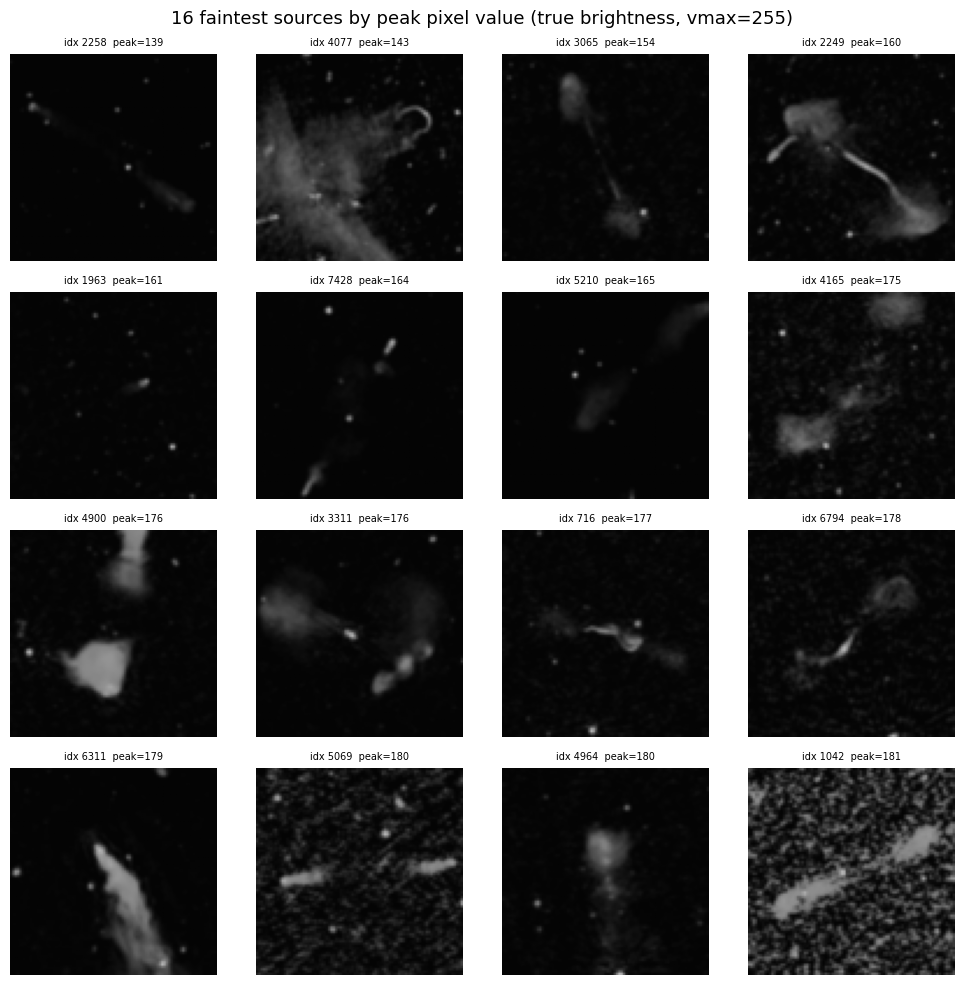

In [23]:
faintest_idx = np.argsort(peak)[:16]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('16 faintest sources by peak pixel value (true brightness, vmax=255)', fontsize=13)
for ax, i in zip(axes.flat, faintest_idx):
    ax.imshow(images[i], cmap='gray', origin='lower', vmin=0, vmax=255)
    ax.set_title(f'idx {i}  peak={peak[i]}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Visualise most homogeneous sources
Sources with the lowest pixel standard deviation — nearly uniform images.

Sources with std=0: 11

   idx  pixel val  source name                               labels
----------------------------------------------------------------------------------------------------
   506        255  ILTJ013122.47+315520.2                    Unknown
   829        255  ILTJ072946.74+255943.9                    none
  1054        255  ILTJ080745.47+641014.4                    FRII, Hybrids, Wings
  2764        255  ILTJ105815.11+280758.3                    FRII
  3498        255  ILTJ120337.34+275635.5                    FRI, C-curvature
  3733        255  ILTJ122301.60+582632.4                    FRI, Relaxed doubles, C-curvature
  3892        255  ILTJ123833.75+275632.2                    FRII, Straight jets
  6042        255  ILTJ154708.63+353853.4                    Spirals
  6098        255  ILTJ155447.76+693311.0                    FRII, C-curvature, Multiple hotspots
  6458        255  ILTJ163200.00+691818.4                    none
  7494        255  ILTJ233822.38+3331

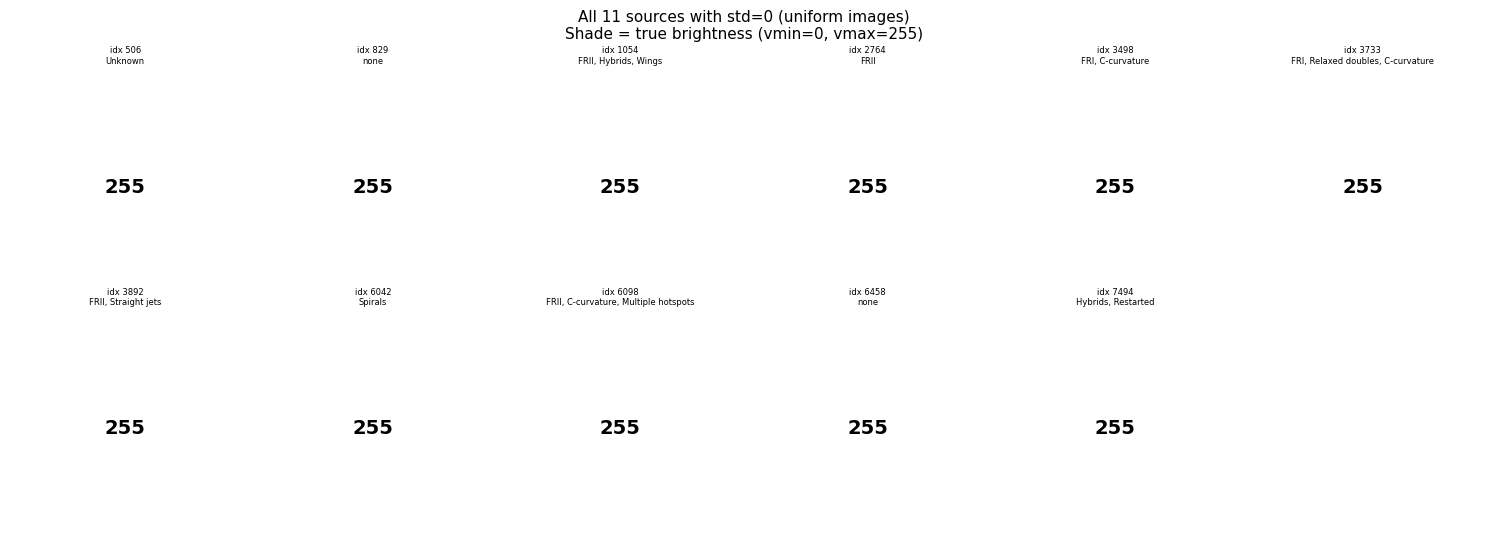

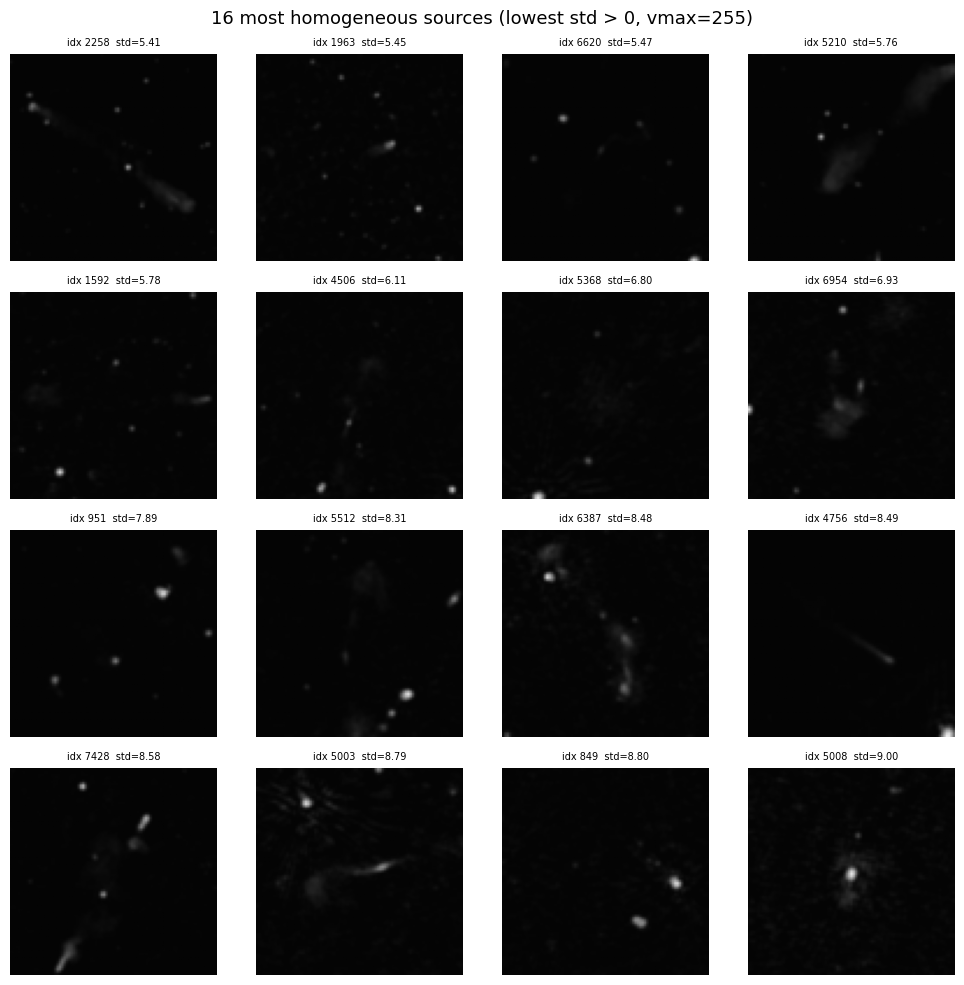

In [32]:
std_per_image = images.astype(np.float32).std(axis=(1, 2))

# --- std=0 sources: list with idx, pixel value, source name, labels ----------
zero_std_idx = np.where(std_per_image == 0)[0]
print(f'Sources with std=0: {len(zero_std_idx)}\n')
print(f'{"idx":>6}  {"pixel val":>9}  {"source name":<40}  labels')
print('-' * 100)
for i in zero_std_idx:
    pixel_val = int(images[i].flat[0])
    source_name = csv.iloc[i]['Source_Name'] if 'Source_Name' in csv.columns else 'N/A'
    active_labels = ', '.join(LABEL_NAMES[labels[i].astype(bool)]) or 'none'
    print(f'{i:>6}  {pixel_val:>9}  {source_name:<40}  {active_labels}')

# --- visualise all std=0 sources ----------------------------------------------
n = len(zero_std_idx)
ncols = min(n, 6)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.8),
                         squeeze=False)
fig.suptitle(f'All {n} sources with std=0 (uniform images)\n'
             f'Shade = true brightness (vmin=0, vmax=255)', fontsize=11)

for ax, i in zip(axes.flat, zero_std_idx):
    pixel_val = int(images[i].flat[0])
    ax.imshow(images[i], cmap='gray', origin='lower', vmin=0, vmax=255)
    text_color = 'white' if pixel_val < 128 else 'black'
    ax.text(44, 44, str(pixel_val), ha='center', va='center',
            fontsize=14, fontweight='bold', color=text_color)
    active = ', '.join(LABEL_NAMES[labels[i].astype(bool)]) or 'none'
    ax.set_title(f'idx {i}\n{active}', fontsize=6)
    ax.axis('off')

for ax in list(axes.flat)[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# --- 16 most homogeneous sources excluding std=0 ------------------------------
nonzero_mask = std_per_image > 0
nonzero_idx = np.where(nonzero_mask)[0]
most_homogeneous_idx = nonzero_idx[np.argsort(std_per_image[nonzero_mask])[:16]]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('16 most homogeneous sources (lowest std > 0, vmax=255)', fontsize=13)
for ax, i in zip(axes.flat, most_homogeneous_idx):
    ax.imshow(images[i], cmap='gray', origin='lower', vmin=0, vmax=255)
    ax.set_title(f'idx {i}  std={std_per_image[i]:.2f}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Filter: remove uniform (std=0) sources

Total sources:  7607
Removed (std=0): 11
Kept:           7596


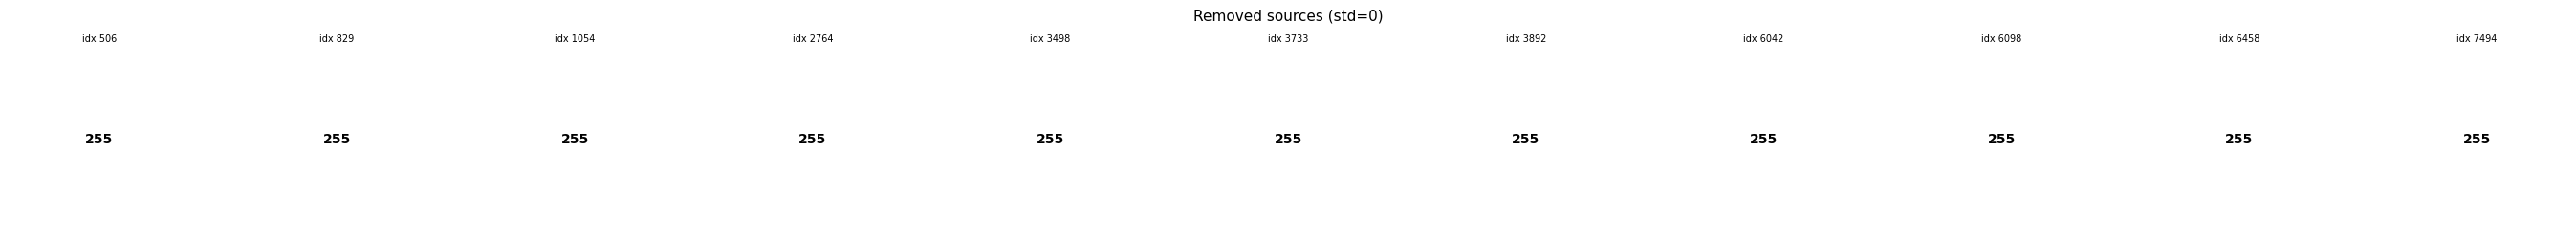

In [33]:
keep_mask = std_per_image > 0
removed_idx = np.where(~keep_mask)[0]

print(f'Total sources:  {len(images)}')
print(f'Removed (std=0): {(~keep_mask).sum()}')
print(f'Kept:           {keep_mask.sum()}')

n_show = len(removed_idx)
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 2.5, 2.5))
if n_show == 1:
    axes = [axes]
fig.suptitle('Removed sources (std=0)', fontsize=11)
for ax, i in zip(axes, removed_idx):
    pixel_val = int(images[i].flat[0])
    ax.imshow(images[i], cmap='gray', origin='lower', vmin=0, vmax=255)
    text_color = 'white' if pixel_val < 128 else 'black'
    ax.text(44, 44, str(pixel_val), ha='center', va='center',
            fontsize=10, fontweight='bold', color=text_color)
    ax.set_title(f'idx {i}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Save filtered dataset

In [34]:
images_filtered = images[keep_mask]
labels_filtered = labels[keep_mask]

print(f'Before: images {images.shape}, labels {labels.shape}')
print(f'After:  images {images_filtered.shape}, labels {labels_filtered.shape}')

np.save(DATA_DIR / 'images_filtered.npy', images_filtered)
np.save(DATA_DIR / 'labels_filtered.npy', labels_filtered)

print(f'\nSaved to:')
print(f'  {DATA_DIR / "images_filtered.npy"}')
print(f'  {DATA_DIR / "labels_filtered.npy"}')

Before: images (7607, 89, 89), labels (7607, 20)
After:  images (7596, 89, 89), labels (7596, 20)

Saved to:
  ../data/images_filtered.npy
  ../data/labels_filtered.npy


## Verify filtered dataset

In [ ]:
std_filtered = images_filtered.astype(np.float32).std(axis=(1, 2))
print(f'Any source with std=0: {(std_filtered == 0).sum()}')

rng2 = np.random.default_rng(0)
sample2 = rng2.choice(len(images_filtered), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Random sample from filtered dataset', fontsize=13)
for ax, i in zip(axes.flat, sample2):
    ax.imshow(images_filtered[i], cmap='gray', origin='lower', vmin=0, vmax=255)
    ax.set_title(f'idx {i}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()